# Watt's the Source? A Look at Oregon's Electricity System (1990-2023)
![Energy Tower](pexels-pok-rie-33563-189524.jpg)

**Course:** CS410 TOP: Data With Python 

**Author:** Ryan Le

## Introduction
This project explores Oregon's electricity system using the State Electricity Profile (SEP) dataset provided by the U.S. Energy Information Administration (EIA). The analysis focuses on trends in generation, capacity, emissions, and the shift toward renewable energy. The goal is to understand how Oregon's electricity landscape has evolved over time and whether it is becoming cleaner, more efficient, and more sustainable.

## Dataset Details
The dataset includes a wide range of electricity related metrics for Oregon.
- **Source**: U.S. Energy Information Administration
- **File**: 'State Electricity Profile Tables for OR.xlsx'
- **Website**: [EIA Oregon Profile](https://www.eia.gov/electricity/state/Oregon/)
- **Time Range**: Most Excel sheets span 1990-2023, but some contain only data for 2023
- **Sheets used in this analysis**:
    - `4. Capacity` - Installed electric power industry capacity by fuel type
    - `5. Generation` - Annual electricity generation by source (MWh)
    - `7. Emissions` - Emissions by type and mass (e.g., CO2, SO2, NOx)
    - `16. Distributed` - Electricity generation from distributed systems (e.g., rooftop solar)

      _**Note:** The full file contains 17 sheets in total, including electricity sales, price data, and utility-level summaries, which were not used in this project. Only sheets with multi-year data were used, as those limited to 2023 lacked the historical context needed to analyze long-term trends relevant to the research questions._

## Dataset Preview and Initial Exploration
Before diving into analysis, we need to preview and understand the structure of each relevant sheet. This helps identify potential issues like missing values, inconsistent formats, or irrelevant rows.

In [1]:
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Excel file and list sheet names
file_path = 'SEP Tables for OR.xlsx'
xls = pd.ExcelFile(file_path)
print("Sheets:", xls.sheet_names)

Sheets: ['1. Summary', '2A. Plants-Capacity', '2B. Plants-Generation', '3 Retailers', '4. Capacity', '5. Generation', '6. Fuel', '7. Emissions', '8. Sales', '9. Ownership', '10. Source-Disposition', '11. Net Metering', '12. AMR-AMI', '13. Energy Efficiency', '14 Capacity Factors Monthly', '15 Capacity Factors Annual', '16. Distributed', '17. Reliability']


## Dataset Cleaning
Many of the sheets contain extra header rows, missing values, and non-numeric entries (like periods or commas) that need to be addressed. To prepare the data for analysis each sheet, these steps are used:
- **Skip metadata rows** at the top of each sheet when needed.
- **Rename** the first column to a clear label (e.g., `Source`).
- **Drop** completely empty rows/columns and note rows (e.g., “Oregon”, unit lines).
- **Keep only 4-digit year columns** (e.g., `1990` … `2023`) so non-year fields like “Percent share 2000” are removed.
- **Convert numbers** by removing commas, turning `"."` into missing values, and applying `to_numeric`.
- **Emissions specific:** locate the **Carbon dioxide** block and select the **Total** row for a single statewide CO₂ series.

#### Cleaning Capacity

In [2]:
# CAPACITY (MW)

# Read and basic cleanup
cap = pd.read_excel(file_path, sheet_name='4. Capacity', skiprows=3)
cap = cap.rename(columns={cap.columns[0]: 'Source'})
cap = cap.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Remove non-data rows
cap = cap[~cap['Source'].isin(['Oregon', 'megawatts'])].copy()

# Normalize headers and detect 4-digit year columns
cap.columns = [str(c).replace('Year\n', '').replace('Year ', '').strip() for c in cap.columns]
year_cols_cap = [c for c in cap.columns if str(c).isdigit()]

# Keep Source + pure year columns (drops "Percent share ..." etc.)
cap = cap[['Source'] + year_cols_cap]

# Coerce year columns to numeric
for c in year_cols_cap:
    cap[c] = pd.to_numeric(
        cap[c].astype(str).str.replace(',', '', regex=False).replace('.', None),
        errors='coerce'
    )

# Useful subsets
cap_total = cap[cap['Source'].str.strip().eq('Total electric industry')].copy()
cap_sources = cap[~cap['Source'].str.lower().isin([
    'total electric industry', 'electric utilities', 'ipp, commercial and industrial'
])].copy()

first_y_cap = int(min(year_cols_cap))
last_y_cap  = int(max(year_cols_cap))
print(f"Capacity years detected: {first_y_cap}–{last_y_cap}")

display(cap.head(8))


Capacity years detected: 1990–2023


,Source,2023,2022,2021,2020,2019,2018,2017,2016,2015,...,1999,1998,1997,1996,1995,1994,1993,1992,1991,1990
0,Electric utilities,11023.6,11031.4,10998.2,10991.6,11453.4,11544.0,11556.9,11556.9,11200.6,...,10293.0,10449.0,10537.0,10526.0,10445.0,10165.0,10132.0,10132.0,11235.0,11235.0
1,Battery,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Coal,NaN,NaN,NaN,NaN,585.0,585.0,585.0,585.0,585.0,...,530.0,528.0,508.0,508.0,508.0,508.0,508.0,508.0,530.0,530.0
3,Geothermal,1.8,1.8,1.8,1.8,1.8,1.8,1.8,1.8,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Hydroelectric,8294.5,8302.3,8268.8,8251.4,8251.4,8331.3,8352.2,8352.2,8454.2,...,9017.0,9032.0,9036.0,9028.0,9030.0,9021.0,9008.0,9010.0,8988.0,8988.0
5,Natural gas,2059.9,2059.9,2059.9,2069.7,2046.5,2057.4,2049.4,2049.4,1591.1,...,498.0,498.0,498.0,498.0,770.0,496.0,496.0,344.0,344.0,344.0
6,..Natural gas - CC,1811.5,1811.5,1811.5,1811.5,1788.3,1799.2,1791.2,1791.2,1332.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,..Natural gas - GT,24.0,24.0,24.0,33.8,33.8,33.8,33.8,33.8,33.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Cleaning Generation

In [3]:
# GENERATION (MWh)

# Read and basic cleanup
gen = pd.read_excel(file_path, sheet_name='5. Generation', skiprows=3)
gen = gen.rename(columns={gen.columns[0]: 'Source'})
gen = gen.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Remove non-data rows
gen = gen[~gen['Source'].isin(['Oregon', 'megawatthours'])].copy()

# Normalize headers and detect pure 4-digit year columns
gen.columns = [str(c).replace('Year\n', '').replace('Year ', '').strip() for c in gen.columns]
year_cols_gen = [c for c in gen.columns if str(c).isdigit()]

# Keep Source + pure year columns (drops "Percent share ..." etc.)
gen = gen[['Source'] + year_cols_gen]

# Coerce year columns to numeric
for c in year_cols_gen:
    gen[c] = pd.to_numeric(
        gen[c].astype(str).str.replace(',', '', regex=False).replace('.', None),
        errors='coerce'
    )

# Build total generation Series (MWh) from the "Total electric industry" row
total_row = gen['Source'].str.strip().eq('Total electric industry')
if not total_row.any():
    raise ValueError("Could not find 'Total electric industry' in Generation sheet.")

total_gen = gen.loc[total_row, year_cols_gen].T.squeeze()
total_gen.index = total_gen.index.astype(int)
total_gen = total_gen.sort_index()

print("Total generation (MWh) preview:")
display(total_gen.head(10))
print(f"Years detected: {int(total_gen.index.min())}–{int(total_gen.index.max())}")


Total generation (MWh) preview:


1990    50372237.0
1991    47444891.0
1992    42345374.0
1993    41909585.0
1994    38440813.0
1995    45265553.0
1996    51011773.0
1997    52412854.0
1998    51148484.0
1999    56848346.0
Name: 43, dtype: float64

Years detected: 1990–2023


#### Cleaning Emissions

In [4]:
# EMISSIONS (CO₂ thousand metric tons)
emi = pd.read_excel(file_path, sheet_name='7. Emissions', skiprows=2)
emi = emi.rename(columns={emi.columns[0]: 'Emission Type'})
emi.columns = [str(c).replace('Year\n', '').replace('Year ', '').strip() for c in emi.columns]

# Find where the "Carbon dioxide" block starts
co2_start = emi[emi['Emission Type'].astype(str).str.contains('Carbon dioxide', case=False, na=False)].index.min()
co2_block = emi.iloc[co2_start:co2_start+12].copy()

# Pick the "Total" row within that block
co2_total_row = co2_block[co2_block['Emission Type'].astype(str).str.strip().eq('Total')]
if co2_total_row.empty:
    raise ValueError("Couldn't find CO₂ 'Total' row. Scroll the Emissions sheet to confirm labels.")

year_cols_emi = [c for c in emi.columns if str(c).isdigit()]
co2_kT = pd.to_numeric(co2_total_row[year_cols_emi].iloc[0], errors='coerce')
co2_kT.index = co2_kT.index.astype(int)
co2_kT = co2_kT.sort_index()

print("CO₂ (thousand metric tons) preview:")
display(co2_kT.head(10))


CO₂ (thousand metric tons) preview:


1990    2055
1991    3852
1992    4906
1993    4712
1994    5941
1995    3311
1996    3849
1997    3385
1998    6952
1999    7059
Name: 17, dtype: int64

## Exploratory Data Analysis 
#### How has total net generation changed?

Understanding total net generation over time provides a baseline context for the rest of the analysis, anchoring comparisons between installed capacity (MW) and actual output (MWh) and enabling intensity metrics such as kg CO₂ per MWh. So the question "How has total net generation changed" arises. The chart is created by taking the “Total electric industry” row from the *Generation* sheet, keeping only the year columns, and plotting them (Total Net Generation TWh).


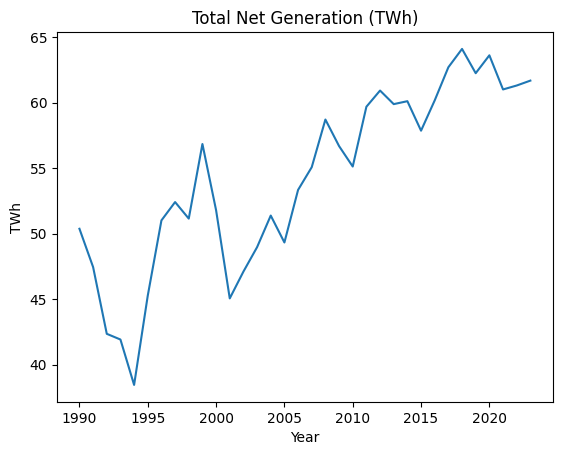

In [5]:
plt.figure()
(total_gen.sort_index()/1000000).plot()
plt.title("Total Net Generation (TWh)")
plt.xlabel("Year"); plt.ylabel("TWh")
plt.show()


In [6]:
tg_twh = (total_gen.sort_index() / 1000000)  # MWh → TWh
fy, ly = int(tg_twh.index[0]), int(tg_twh.index[-1])
fv, lv = float(tg_twh.iloc[0]), float(tg_twh.iloc[-1])
abs_chg = lv - fv
pct_chg = (abs_chg / fv) * 100

print(f"{fy}: {fv:.1f} TWh  ->  {ly}: {lv:.1f} TWh")
print(f"Change: {abs_chg:+.1f} TWh  ({pct_chg:+.1f}%)")


1990: 50.4 TWh  ->  2023: 61.7 TWh
Change: +11.3 TWh  (+22.5%)


The data shows that the total net generation has increased overall from 50.4 TWh to 61.7 TWh. 

#### Q1. Which fuel sources gained or lost the most capacity?

Installed capacity (MW) reflects the system’s potential peak output; large positive shifts indicate new builds or uprates, while negative shifts indicate retirements or derates. The analysis uses the *Capacity* sheet’s **Total electric industry** block, keeps the year columns, and collapses sub-types to a base fuel (e.g., “Natural gas – CC/GT” -> “Natural gas”, “Solar – PV” -> “Solar”). 

For each fuel, capacity in the first available year is compared with the last available year to compute the change (ΔMW), and the largest increases and largest decreases are shown in tables and bar charts.

Capacity change from 1990 to 2023 (TOTAL section, Grouped)


,Source,Change_MW
10,Wind,7952.0
4,Natural gas,7178.8
9,Solar,2021.4
11,Wood,54.3
7,Other biomass,40.6
0,Battery,35.0
2,Geothermal,19.5


,Source,Change_MW
5,Nuclear,-1104.0
3,Hydroelectric,-717.8
1,Coal,-543.0
6,Other,-148.0
8,Petroleum,-102.8


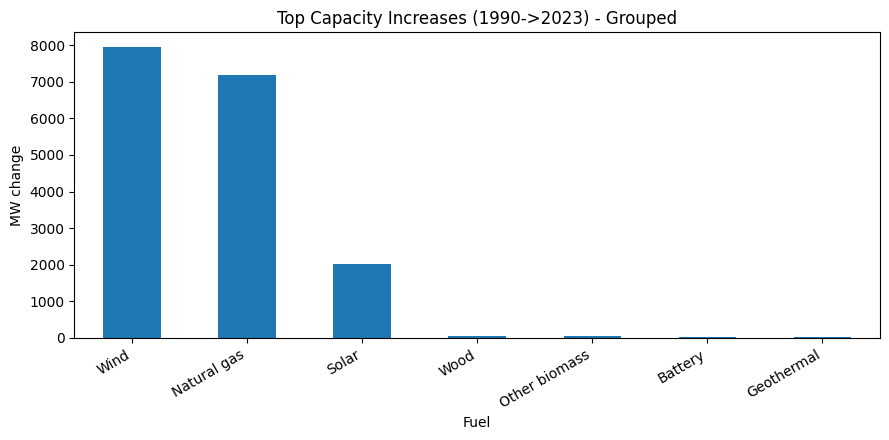

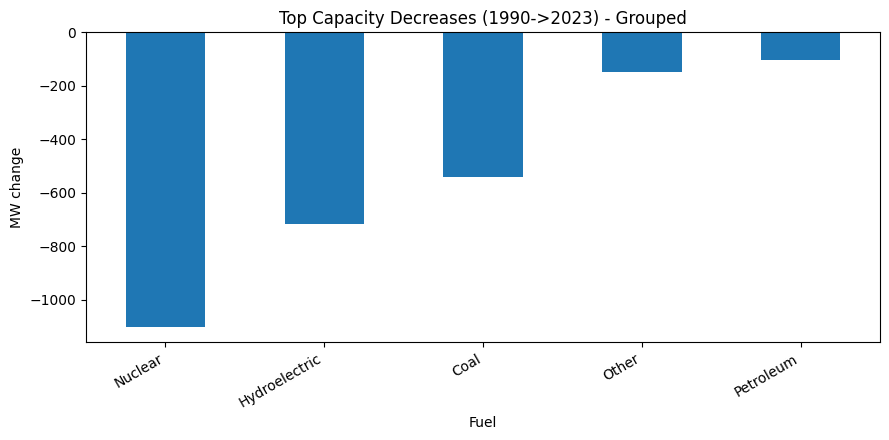

In [7]:
# Q1 - Total section only, drop footnotes, group fuels, filter positives

# Slice the TOTAL section in Capacity
idx_total_cap = cap.index[cap['Source'].str.strip().eq('Total electric industry')][0]
cap_total_section = cap.iloc[idx_total_cap+1:].reset_index(drop=True).copy()

# Drop footnotes/notes rows
note_mask = cap_total_section['Source'].astype(str).str.contains('includes|Source:', case=False, na=False)
cap_total_section = cap_total_section[~note_mask].copy()

# Collapse sub-types to a Base fuel
cap_simple = cap_total_section.copy()
cap_simple['Source'] = (
    cap_simple['Source'].astype(str)
    .str.lstrip('.')
    .str.split(' - ').str[0]
    .str.replace('Solar - PV', 'Solar', regex=False)
    .str.replace('Solar- PV',  'Solar', regex=False)
    .str.strip()
)

# Sum first/last years by Source and compute the change
chg = cap_simple.groupby('Source')[[str(first_y_cap), str(last_y_cap)]].sum().reset_index()
chg['Change_MW'] = chg[str(last_y_cap)] - chg[str(first_y_cap)]

# Top increases (positives) and decreases (negatives)
top_inc = chg[chg['Change_MW'] > 0].sort_values('Change_MW', ascending=False).head(8)
top_dec = chg[chg['Change_MW'] < 0].sort_values('Change_MW').head(8)

print(f"Capacity change from {first_y_cap} to {last_y_cap} (TOTAL section, Grouped)")
display(top_inc[['Source','Change_MW']])
display(top_dec[['Source','Change_MW']])

# Ploting the data
plt.figure(figsize=(9,4.5))
top_inc.set_index('Source')['Change_MW'].plot(kind='bar')
plt.title(f"Top Capacity Increases ({first_y_cap}->{last_y_cap}) - Grouped")
plt.xlabel("Fuel"); plt.ylabel("MW change")
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,4.5))
top_dec.set_index('Source')['Change_MW'].plot(kind='bar')
plt.title(f"Top Capacity Decreases ({first_y_cap}->{last_y_cap}) - Grouped")
plt.xlabel("Fuel"); plt.ylabel("MW change")
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


Using the Total industry section avoids double counting and grouping sub-types gives one bar per fuel making it easier to read and digest. Capacity growth since 1990 is dominated by Wind and Natural Gas, while Nuclear, Hydroelectric, and Coal show net declines driven by retirements and resource changes.

#### Q2. Is Oregon becoming more dependent on renewables?

Renewable dependence is measured as the share of total generation coming from renewable sources. Renewables are defined as hydroelectric, wind, solar, geothermal, and biomass/wood. For each year, generation from these fuels is summed and divided by total generation to produce a percentage; the series is plotted and the change (in % points) from the first to the last year is reported.


,First year %,Last year %,Change (%)
0,83.645265,79.650359,-3.994906


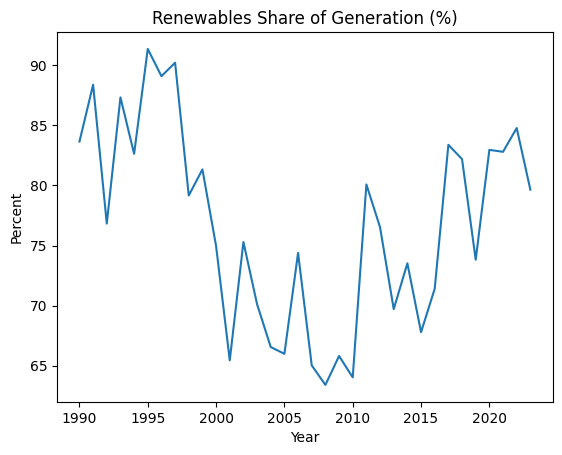

In [8]:
# Q2 Renewable shares

# Locate the "Total electric industry" section and use only that block of rows
idx_total = gen.index[gen['Source'].str.strip().eq('Total electric industry')][0]
gen_total_section = gen.iloc[idx_total+1:].reset_index(drop=True).copy()

# Build renewables from total section only
renew_mask = gen_total_section['Source'].str.contains('Hydro|Wind|Solar|Geothermal|Wood|Biomass', case=False, regex=True)
gen_renew = gen_total_section.loc[renew_mask, year_cols_gen].sum(axis=0)
gen_renew.index = gen_renew.index.astype(int)
gen_renew = gen_renew.sort_index()

# Total generation from the single total row you already built (total_gen)
renew_share = (gen_renew / total_gen).dropna() * 100

first_y_rs, last_y_rs = int(renew_share.index.min()), int(renew_share.index.max())
display(pd.DataFrame({
    "First year %": [renew_share.loc[first_y_rs]],
    "Last year %":  [renew_share.loc[last_y_rs]],
    "Change (%)":  [renew_share.loc[last_y_rs] - renew_share.loc[first_y_rs]],
}))

plt.figure()
renew_share.plot()
plt.title("Renewables Share of Generation (%)")
plt.xlabel("Year"); plt.ylabel("Percent")
plt.show()


Renewables start around 84% in 1990 and are around 80% in 2023 (−4% overall), with a trough in the mid-2000s and a rebound after 2010. The dip and recovery likely reflect hydrologic variability (lower hydro output in dry years), growth in natural gas generation in the 2000s, and the post-2010 expansion of wind and solar. The generation of renewables in other energy types could have offset parts of the hydroelectric swings. But, the exact causes are outside the scope of this dataset, so these are plausible answers and not necessary definitive.

#### Q3. Do changes in fossil generation track CO₂ emissions?

Fossil generation is defined as coal, natural gas, petroleum, and other gas. For each year, fossil MWh are summed and aligned with total CO₂ emissions (thousand metric tons) from the *Emissions* sheet. A Pearson correlation is then computed and a scatter plot is shown to assess the linear association between the two series. Pearson’s *r* ranges from −1 to +1. Values that are closer to +1 indicate that higher fossil generation is associated with higher CO₂. Values near 0 indicate little linear relationship. Values near −1 indicate an inverse relationship.


Pearson correlation (Fossil TWh vs CO₂ thousand tons): 0.770


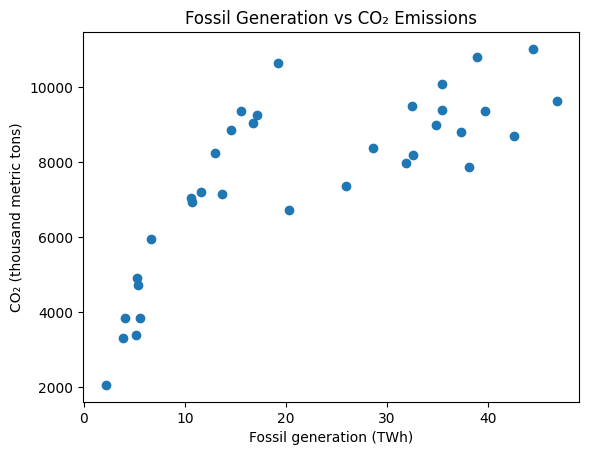

In [9]:
# Q3  Fossil generation

# Use the Total electric industry block from Generation
idx_total = gen.index[gen['Source'].str.strip().eq('Total electric industry')][0]
gen_total_section = gen.iloc[idx_total+1:].reset_index(drop=True).copy()

# Build a fossil mask (coal, natural gas, petroleum, other gas)
col0 = gen_total_section['Source'].astype(str).str.lower()
fossil_mask = (
    col0.str.contains('coal', regex=False) |
    col0.str.contains('natural gas', regex=False) |
    col0.str.contains('petroleum', regex=False) |
    col0.str.contains('other gas', regex=False)
)

# Sum fossil MWh by year and convert to TWh
gen_fossil_mwh = gen_total_section.loc[fossil_mask, year_cols_gen].sum(axis=0)
gen_fossil_mwh.index = gen_fossil_mwh.index.astype(int)
gen_fossil_mwh = gen_fossil_mwh.sort_index()
gen_fossil_twh = gen_fossil_mwh / 1000000  # MWh → TWh

# Align years and compute Pearson correlation on TWh
common_years = [y for y in gen_fossil_twh.index if y in co2_kT.index]
df_corr = pd.DataFrame({
    'Fossil_TWh': gen_fossil_twh.loc[common_years].values,
    'CO2_kT':     co2_kT.loc[common_years].values
}, index=common_years)

r = df_corr['Fossil_TWh'].corr(df_corr['CO2_kT'])
print(f"Pearson correlation (Fossil TWh vs CO₂ thousand tons): {r:.3f}")

# Scatter plot
plt.figure()
plt.scatter(df_corr['Fossil_TWh'], df_corr['CO2_kT'])
plt.title("Fossil Generation vs CO₂ Emissions")
plt.xlabel("Fossil generation (TWh)")
plt.ylabel("CO₂ (thousand metric tons)")
plt.show()


The Pearson correlation helps see if there is a linear relationship between two variables. This helps answer the question if there is a correlation. So the Pearson correlation between fossil generation and CO₂ is 0.77, which indicates a strong positive linear relationship. In years when Oregon produced more electricity from fossil fuels, total CO₂ emissions were typically higher. Therefore, this supports (but doesn’t prove) the idea that the generation mix influences emissions.

#### Q4. Is the system getting cleaner? (CO₂ intensity)

While the data also lists other emssion types, this question focuses specifically on CO₂. CO₂ intensity (kg CO₂/MWh) measures emissions per unit of electricity and controls for changes in total output. The time series is constructed by taking the *Emissions* sheet’s statewide CO₂ total (thousand metric tons), converting to kg, aligning years with total net generation, and dividing by MWh to obtain kg/MWh. The plot shows whether the electricity mix has become cleaner (lower intensity) or dirtier (higher intensity) over time.

CO₂ intensity (kg/MWh) first/last:


1990     40.796282
2023    156.195624
dtype: float64

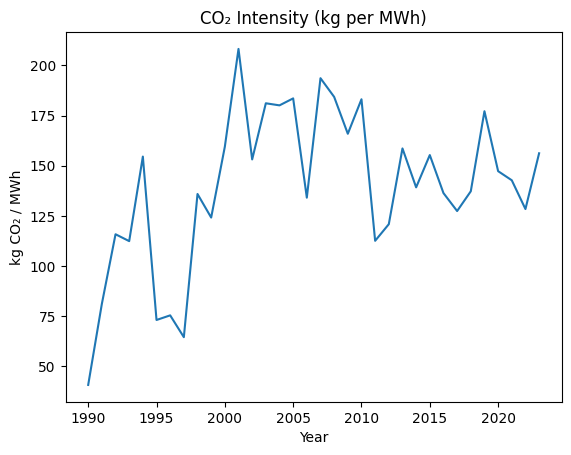

In [10]:
co2_kg = co2_kT * 1000000.0  # thousand metric tons → kg

# Align with total generation
years_int = sorted(set(co2_kg.index) & set(total_gen.index))
co2_intensity = (co2_kg.loc[years_int] / total_gen.loc[years_int]).dropna()

# Report first/last
first_y_int, last_y_int = years_int[0], years_int[-1]
print("CO₂ intensity (kg/MWh) first/last:")
display(co2_intensity.loc[[first_y_int, last_y_int]])

plt.figure()
co2_intensity.plot()
plt.title("CO₂ Intensity (kg per MWh)")
plt.xlabel("Year"); plt.ylabel("kg CO₂ / MWh")
plt.show()


While CO₂ intensity level rises and falls over the years, There has not been much difference. Annual CO₂ intensity shows a pronounced hump in the mid-2000s (peak around 200 kg/MWh), followed by a decline after 2010. Averages for 1991–1994 and 2020–2023 are similar, suggesting little net change over the full period, even though the system became much dirtier in the 2000s and then partially cleaned up in the 2010s. This pattern is consistent with shifts in the generation mix (hydrology, growth of natural gas in the 2000s, and wind/solar expansion after 2010).

#### Q5. How diverse is Oregon’s generation mix?

Typically the Herfindahl Hirschman Index (HHI) is used to measure concentration, and here it summarizes how concentrated Oregon’s generation mix is. HHI is computed as the sum of squared fuel shares in a year and ranges from 0 to 1. Lower values mean a more diverse mix while higher values mean the mix is dominated by fewer fuels. For example, a fuel at 100% gives HHI = 1.00 and 4 equal fuels give HHI = 0.25.

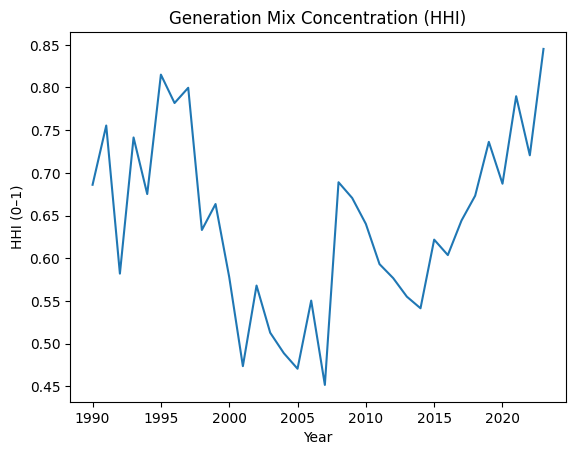

HHI (lower = more diverse) — first & last years:


1990    0.686092
2023    0.845169
dtype: float64

In [11]:
# Q5 HHI 

#  Slice the total-industry block of rows in the Generation table
idx_total = gen.index[gen['Source'].str.strip().eq('Total electric industry')][0]
gen_total_section = gen.iloc[idx_total+1:].reset_index(drop=True).copy()

# Build grouped generation by simple name patterns
patterns = {
    'Coal': 'Coal',
    'Natural gas': 'Natural gas',
    'Petroleum': 'Petroleum',
    'Other gas': 'Other gas',
    'Hydro': 'Hydro',
    'Wind': 'Wind',
    'Solar': 'Solar',
    'Geothermal': 'Geothermal',
    'Biomass': 'Wood|Biomass',
    'Nuclear': 'Nuclear'
}

mix = {}
for name, pat in patterns.items():
    rows = gen_total_section['Source'].str.contains(pat, case=False, regex=True)
    series = gen_total_section.loc[rows, year_cols_gen].sum(axis=0)
    series.index = series.index.astype(int)
    mix[name] = series

mix = pd.DataFrame(mix).sort_index()

# Compute shares and HHI on the 0–1 scale
shared_years = sorted(set(mix.index) & set(total_gen.index))
mix = mix.loc[shared_years]
shares = mix.div(total_gen.loc[shared_years].values, axis=0).fillna(0.0)

hhi = (shares ** 2).sum(axis=1)

plt.figure()
hhi.plot()
plt.title("Generation Mix Concentration (HHI)")
plt.xlabel("Year"); plt.ylabel("HHI (0–1)")
plt.show()

print("HHI (lower = more diverse) — first & last years:")
display(hhi.loc[[shared_years[0], shared_years[-1]]])


Oregon’s generation mix has become less diverse over the 1990-2023 period. The HHI starts around 0.69 in 1990, dips to a low near 0.45 in the mid-2000s (most diversified), then rises steadily to about 0.85 in 2023, indicating greater concentration in a few fuels. This pattern suggests that in recent years the mix is dominated by a small set of sources, primarily hydroelectric, natural gas, and growth in wind and solar. Higher or lower HHI is not good or bad by itself; it only describes concentration, so it should be interpreted alongside reliability and emissions.

## Conclusions

From 1990 to 2023, Oregon’s electricity system changed in several clear ways. Installed capacity shifted toward wind and natural gas, while nuclear, hydroelectric, and coal showed net declines consistent with retirements. Renewables still supply the majority of in-state generation; the renewable share is about 84% in 1990 and about 80% in 2023 (about 4% lower overall), with a dip in the mid-2000s and a rebound after 2010 that largely tracks hydrologic variability and the expansion of wind and solar. Fossil generation and CO₂ emissions move together, with a Pearson correlation of about 0.77, indicating a strong positive linear association. CO₂ intensity (kg per MWh) rises into the mid-2000s, then declines; recent values are in the same ballpark as the early 1990s, suggesting little net change over the full period despite a pronounced mid-2000s peak. Diversity, summarized by the Herfindahl Hirschman Index, falls over time: HHI rises from about 0.69 in 1990 to about 0.85 in 2023, meaning the mix is more concentrated in a smaller set of fuels in recent years, mainly hydroelectric and natural gas even as wind and solar grow. Lower diversity is not inherently good or bad; it describes concentration and should be interpreted alongside reliability, emissions, hydrology exposure, and fuel-price risk. In-state coal generation ends in 2020 with the closure of the Boardman plant, and Oregon’s only nuclear plant (Trojan) ceased operations in 1993; imports can still contain those fuels, but the in-state capacity and generation reported here reflect these closures.

#### Limitations

State-level annual data can mask plant-level dynamics, the role of imports and exports, and year-specific hydrology. Some tables include embedded notes and sectional totals that require careful selection to avoid double counting. Correlation does not imply causation; additional controls would be needed to attribute drivers of change.

#### Potential Areas for Future Investigation

This project provides a high-level, state-level view using annual EIA tables, so not every topic or driver is explored in detail. Future work could use monthly or seasonal data to separate wet or dry hydro years from longer trends, relate the generation mix to reliability and retail prices, and split changes in CO₂ per MWh into mix effects versus within-fuel efficiency changes.
